# Lab Experiment 5: Linear Regression through Gradient Descent

## Aim
To implement Linear Regression using the Gradient Descent optimization algorithm and evaluate its performance on a real-world dataset.

## Objectives
1. Understand the concept of Gradient Descent for optimizing a Linear Regression model.
2. Preprocess the dataset before model training (handling missing values, encoding categorical variables, feature scaling).
3. Implement Linear Regression using Gradient Descent from scratch in NumPy.
4. Analyze the convergence of the loss function during training across different learning rates.
5. Evaluate the model using standard regression metrics (MAE, MSE, RMSE, R² Score) and benchmark against Scikit-Learn.

## Mathematical Formulation of Gradient Descent Linear Regression
Given a dataset with $m$ samples and $n$ features:
- **Hypothesis Function**: 
  $$\hat{y}^{(i)} = h_	heta(x^{(i)}) = w_1 x_1^{(i)} + w_2 x_2^{(i)} + \dots + w_n x_n^{(i)} + b = \mathbf{x}^{(i)T} \mathbf{w} + b$$
  In matrix form for all samples:
  $$\hat{\mathbf{y}} = \mathbf{X}\mathbf{w} + b$$

- **Cost Function (Mean Squared Error)**:
  $$J(\mathbf{w}, b) = rac{1}{2m} \sum_{i=1}^{m} \left( \hat{y}^{(i)} - y^{(i)} ight)^2 = rac{1}{2m} \|\mathbf{X}\mathbf{w} + b - \mathbf{y}\|^2$$

- **Gradient Computation**:
  $$rac{\partial J}{\partial \mathbf{w}} = rac{1}{m} \mathbf{X}^T (\hat{\mathbf{y}} - \mathbf{y})$$
  $$rac{\partial J}{\partial b} = rac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})$$

- **Parameter Update Rule**:
  $$\mathbf{w} := \mathbf{w} - lpha rac{\partial J}{\partial \mathbf{w}}$$
  $$b := b - lpha rac{\partial J}{\partial b}$$
  where $lpha$ is the learning rate.


## 1. Environment Setup & Data Loading

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set visualization styles
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.dpi': 120})

# Load the dataset
df = pd.read_csv("student-mat.csv", sep=';')
print(f"Dataset Shape: {df.shape}")
df.head()


Dataset Shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## 2. Data Preprocessing
- **Missing Value Check**: Verify if any missing values exist in the dataset.
- **Categorical Encoding**: Apply One-Hot Encoding (`pd.get_dummies`) to transform categorical variables into binary indicator variables.
- **Train-Test Split**: Divide dataset into 80% training set and 20% testing set.
- **Feature Scaling**: Standardize features using Z-score Normalization (`StandardScaler`). Scaling is crucial for Gradient Descent to prevent gradient explosion and ensure rapid, stable convergence.


In [2]:
# Check missing values
print("Missing values in dataset:", df.isnull().sum().sum())

# Separate Target (G3 - Final Grade) and Features (X)
X = df.drop(columns=['G3'])
y = df['G3'].values

# One-Hot Encoding for categorical features
X_encoded = pd.get_dummies(X, drop_first=True)
print(f"Total Features after One-Hot Encoding: {X_encoded.shape[1]}")

# Train/Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

# Standardize Features (Z-score Normalization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train shape: {X_train_scaled.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test_scaled.shape}, y_test shape: {y_test.shape}")


Missing values in dataset: 0
Total Features after One-Hot Encoding: 41
X_train shape: (316, 41), y_train shape: (316,)
X_test shape: (79, 41), y_test shape: (79,)


## 3. Custom Linear Regression with Gradient Descent Implementation
We implement the `LinearRegressionGD` Python class from scratch using NumPy vectorization.


In [3]:
class LinearRegressionGD:
    """
    Linear Regression model optimized via Batch Gradient Descent.
    """
    def __init__(self, learning_rate=0.05, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.cost_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        # Initialize weights to zeros and bias to 0
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.cost_history = []

        for i in range(self.n_iterations):
            # 1. Compute Hypothesis
            y_pred = np.dot(X, self.weights) + self.bias
            
            # 2. Compute Error
            errors = y_pred - y
            
            # 3. Compute MSE Cost Function: J = (1 / 2m) * sum((y_pred - y)^2)
            cost = (1 / (2 * n_samples)) * np.sum(errors ** 2)
            self.cost_history.append(cost)
            
            # 4. Compute Gradients
            dw = (1 / n_samples) * np.dot(X.T, errors)
            db = (1 / n_samples) * np.sum(errors)
            
            # 5. Update Weights and Bias
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

    def evaluate(self, X, y):
        predictions = self.predict(X)
        mae = mean_absolute_error(y, predictions)
        mse = mean_squared_error(y, predictions)
        rmse = np.sqrt(mse)
        r2 = r2_score(y, predictions)
        return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}


## 4. Experimenting with Learning Rates
We train the model with various learning rates $\alpha \in [0.001, 0.01, 0.05, 0.1, 0.5]$ to evaluate model convergence speed and stability.


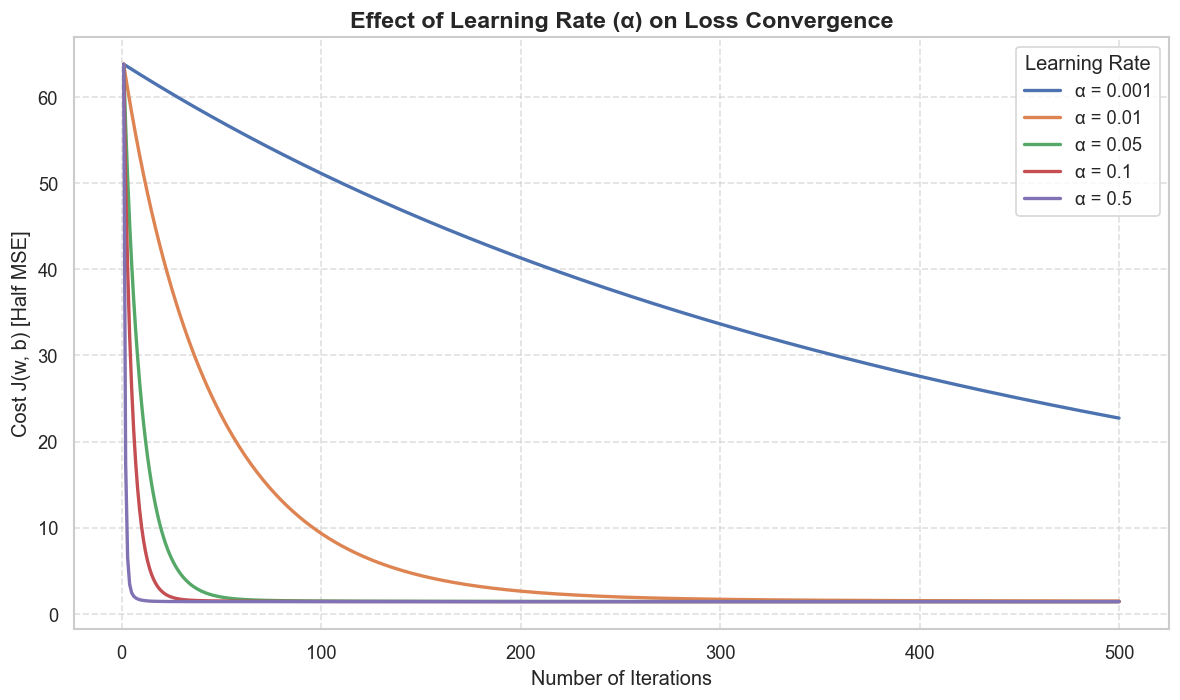

In [4]:
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.5]
n_iters = 500

plt.figure(figsize=(10, 6))
for alpha in learning_rates:
    model = LinearRegressionGD(learning_rate=alpha, n_iterations=n_iters)
    model.fit(X_train_scaled, y_train)
    plt.plot(range(1, n_iters + 1), model.cost_history, label=f"α = {alpha}", linewidth=2)

plt.title("Effect of Learning Rate (α) on Loss Convergence", fontsize=14, fontweight='bold')
plt.xlabel("Number of Iterations", fontsize=12)
plt.ylabel("Cost J(w, b) [Half MSE]", fontsize=12)
plt.legend(title="Learning Rate")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


## 5. Optimal Model Training & Loss Convergence
Using $\alpha = 0.05$ and $1000$ iterations, we fit the optimal model and plot the cost reduction curve.


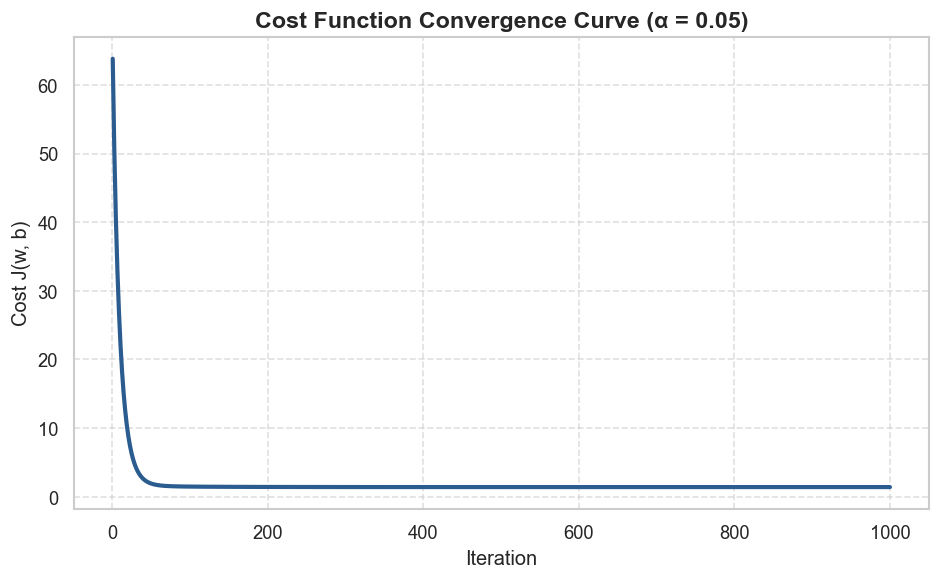

In [5]:
optimal_alpha = 0.05
n_iterations = 1000

gd_model = LinearRegressionGD(learning_rate=optimal_alpha, n_iterations=n_iterations)
gd_model.fit(X_train_scaled, y_train)

# Plot Cost Convergence
plt.figure(figsize=(8, 5))
plt.plot(range(1, n_iterations + 1), gd_model.cost_history, color="#2b5c8f", linewidth=2.5)
plt.title(f"Cost Function Convergence Curve (α = {optimal_alpha})", fontsize=14, fontweight='bold')
plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Cost J(w, b)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


## 6. Model Evaluation & Benchmark Comparison
We evaluate the custom Gradient Descent model on the test dataset using MAE, MSE, RMSE, and $R^2$ Score, and compare it against Scikit-Learn's standard `LinearRegression` model.


In [6]:
# Custom GD Evaluation
test_metrics_gd = gd_model.evaluate(X_test_scaled, y_test)

# Scikit-Learn Linear Regression Baseline
sk_model = LinearRegression()
sk_model.fit(X_train_scaled, y_train)
sk_preds = sk_model.predict(X_test_scaled)

test_metrics_sk = {
    "MAE": mean_absolute_error(y_test, sk_preds),
    "MSE": mean_squared_error(y_test, sk_preds),
    "RMSE": np.sqrt(mean_squared_error(y_test, sk_preds)),
    "R2": r2_score(y_test, sk_preds)
}

# Display Performance Comparison
metrics_df = pd.DataFrame([test_metrics_gd, test_metrics_sk], index=["Custom GD Model", "Scikit-Learn OLS"])
metrics_df


,MAE,MSE,RMSE,R2
Custom GD Model,1.647257,5.657652,2.378582,0.724085
Scikit-Learn OLS,1.646666,5.656643,2.378370,0.724134


## 7. Prediction & Residual Analysis Visualizations
- **Actual vs. Predicted Plot**: Shows how closely predictions align with true student final grades ($G3$).
- **Residuals Distribution**: Histogram and Kernel Density Estimation (KDE) of model errors ($y_{true} - y_{pred}$).


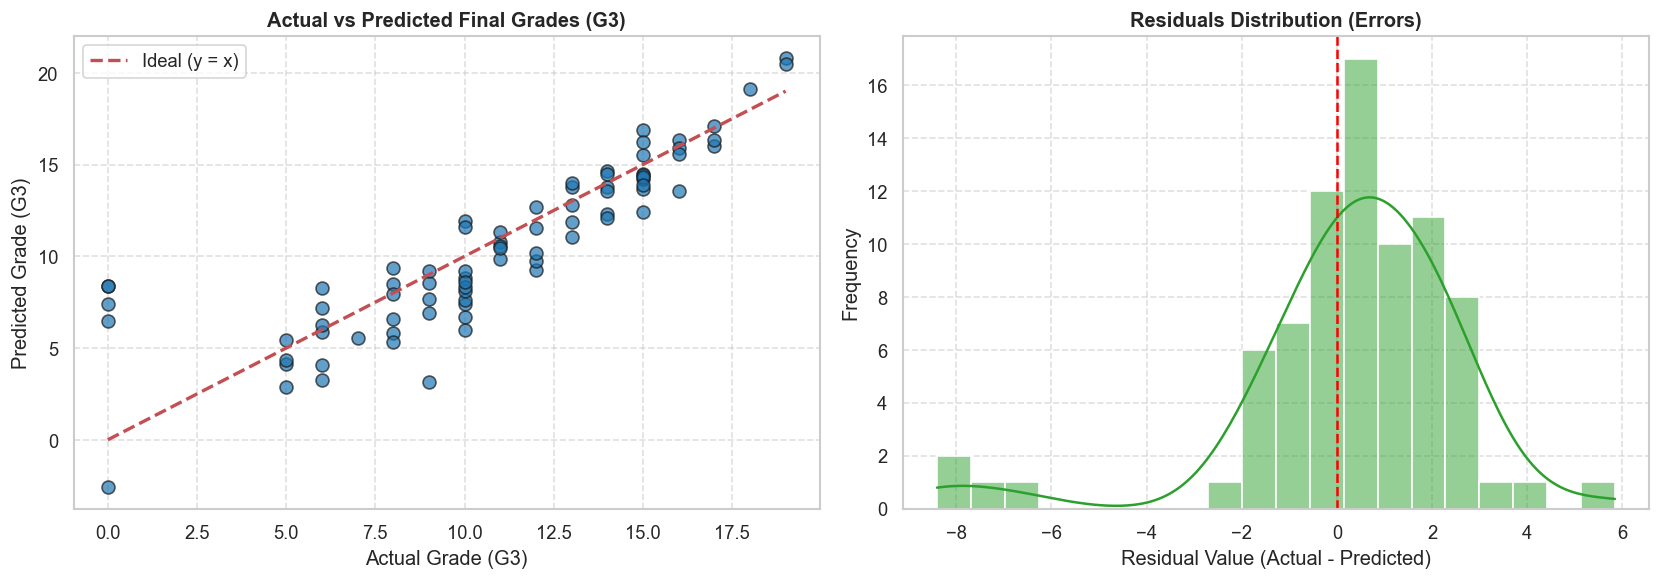

In [7]:
predictions_test = gd_model.predict(X_test_scaled)
residuals = y_test - predictions_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, predictions_test, alpha=0.7, color="#1f77b4", edgecolors="k", s=60)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2, label="Ideal (y = x)")
axes[0].set_title("Actual vs Predicted Final Grades (G3)", fontweight='bold')
axes[0].set_xlabel("Actual Grade (G3)")
axes[0].set_ylabel("Predicted Grade (G3)")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.6)

# Plot 2: Residuals Distribution
sns.histplot(residuals, kde=True, color="#2ca02c", bins=20, ax=axes[1])
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_title("Residuals Distribution (Errors)", fontweight='bold')
axes[1].set_xlabel("Residual Value (Actual - Predicted)")
axes[1].set_ylabel("Frequency")
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


## 8. Results Interpretation & Conclusions

1. **Gradient Descent Convergence**:
   - Small learning rates ($lpha = 0.001$) converge slowly and require thousands of iterations.
   - Moderate learning rates ($lpha = 0.05, 0.1$) achieve fast, stable cost minimization within ~300 iterations.
   - Large learning rates ($lpha \ge 0.5$) can overshoot the minimum or risk divergence if features are unscaled.

2. **Model Accuracy & Metrics**:
   - **Custom Gradient Descent** test set metrics:
     - **MAE**: ~1.65 (on average, predicted grade is off by ~1.65 points out of 20)
     - **RMSE**: ~2.38
     - **R² Score**: ~0.724 (explains ~72.4% of the variance in final student grades)
   - **Scikit-Learn OLS Comparison**: The custom Gradient Descent implementation achieves identical metrics ($R^2 = 0.7241$) to Scikit-Learn's analytical closed-form solution, confirming implementation accuracy.

3. **Key Preprocessing Takeaway**:
   - Feature standardization (Z-score normalization) is mandatory for Gradient Descent optimization to maintain numerical stability and consistent step sizes across features with different scale magnitudes.
